# Imports

In [31]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import f1_score, confusion_matrix, classification_report, precision_recall_curve
from sklearn.model_selection import train_test_split, TunedThresholdClassifierCV, cross_validate, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder, OneHotEncoder, TargetEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif, RFE
#from utils_modeling import (run_gridsearch, DataCleaner)
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.base import clone
import pickle
SEED = 23 

pd.options.display.float_format = '{:.3f}'.format
pd.options.display.max_columns = None

In [32]:
%cd ..
data = pd.read_csv('Datasets/donors_train.csv', index_col=0)
test = pd.read_csv('Datasets/donors_test.csv', index_col=0)
%cd Modeling (IGNORAR PARA JÁ)

c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project
c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project\Modeling (IGNORAR PARA JÁ)


# Other/Extra

## Modeling

### NaN

In [3]:
num_cols = data.select_dtypes(include=np.number).columns.drop(['TARGET_B'])

cat_cols = list(data.select_dtypes(include='str').columns) 

In [4]:
set(num_cols) & set(cat_cols)

set()

In [5]:
set(data.columns) - (set(num_cols) | set(cat_cols))

{'TARGET_B'}

In [6]:
X = data.drop(['TARGET_B'], axis=1)
y = data['TARGET_B']

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=SEED)

## Classes

In [8]:
X[num_cols].dtypes.value_counts()

float64    34
Name: count, dtype: int64

In [9]:
class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self,
                 rules:dict,
                 method:str = 'percentile'):
        self.method = method
        self.rules = rules
        self.learned_limits_ = {}

    def fit(self, X, y=None):
        for var, rules in self.rules.items():
            lower_rule = rules.get('lower')
            upper_rule = rules.get('upper')
            if self.method.lower() == 'percentile_individual':
                lower_limit = X[var].quantile(lower_rule) if lower_rule is not None else None
                upper_limit = X[var].quantile(upper_rule) if upper_rule is not None else None
                self.learned_limits_[var] = {'lower': lower_limit, 'upper': upper_limit}
            else:
                self.learned_limits_[var] = {'lower': lower_rule, 'upper': upper_rule}
        return self
    
    def transform(self, X):
        X = X.copy()
        for var, limits in self.learned_limits_.items():
            lower = limits.get('lower')
            upper = limits.get('upper')
            X[var] = X[var].clip(lower=lower, upper=upper)
        return X
    
    # Adding this allows set_output to work
    def get_feature_names_out(self, input_features=None):
        # We dropped 'WEALTH_RATING' and added two new ones
        # This keeps scikit-learn pipelines happy
        features = [f for f in self.feature_names_in_ if f != 'WEALTH_RATING']
        features.extend(['LIFETIME_AVG_GIFT_AMT', 'LIFETIME_GIFT_AMT_RANGE'])
        return np.array(features)
                

In [10]:
def check_decimals(val, threshold=3):
    # Convert to string and split by the decimal point
    str_val = str(val)
    if '.' in str_val:
        decimals = str_val.split('.')[1]
        if len(decimals) > threshold:
            return np.nan
    return val


In [11]:
class DataCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, numerical_cols:list):
        self.numerical_cols = numerical_cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X = X.replace('?', np.nan)
        X[self.numerical_cols] = X[self.numerical_cols].map(check_decimals)
        X[self.numerical_cols] = X[self.numerical_cols].abs()
        X['HOME_OWNER'] = X['HOME_OWNER'].apply(lambda x: 1 if x == 'H' else 0)
        X.loc[(X['DONOR_AGE'] < 18) | (X['DONOR_AGE'] > 100), 'DONOR_AGE'] = np.nan
        X.loc[(X['RECENT_STAR_STATUS'] % 1 != 0), 'RECENT_STAR_STATUS'] = np.nan
        X.loc[(X['RECENT_STAR_STATUS'] > 1), 'RECENT_STAR_STATUS'] = 1
        X.loc[(~X['PEP_STAR'].isin([0,1])), 'PEP_STAR'] = np.nan
        X.loc[(~X['WEALTH_RATING'].isin(np.arange(1,11))), 'WEALTH_RATING'] = np.nan
        X.loc[(~X['INCOME_GROUP'].isin(np.arange(1, 8))), 'INCOME_GROUP'] = np.nan
        X['LIFETIME_AVG_GIFT_AMT'] = X['LIFETIME_GIFT_AMOUNT'] / X['LIFETIME_GIFT_COUNT']
        X['LIFETIME_GIFT_AMT_RANGE'] = X['LIFETIME_MAX_GIFT_AMT'] - X['LIFETIME_MIN_GIFT_AMT']
        X.drop('WEALTH_RATING', axis=1)
        X['SES'] = X['SES'].astype('Int64')
        return X
    
    # Adding this allows set_output to work
    def get_feature_names_out(self):
        return self.feature_names_in_

In [12]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LassoCV, RidgeCV, LogisticRegressionCV
from scipy.stats import chi2_contingency

class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, 
                 categorical_cols: list,
                 numerical_cols: list,
                 p_value: float = 0.05,
                 corr_threshold: float = 0.8):
        self.p_value = p_value
        self.corr_threshold = corr_threshold
        self.categorical_cols = categorical_cols
        self.numerical_cols = numerical_cols
        self.cols_to_keep_ = []

    def fit(self, X, y):
        votes_to_remove = {col: 0 for col in X.columns}
        y_series = pd.Series(y).reset_index(drop=True)
        n_features = X.shape[1]

        # --- 1. Chi-Square for Categorical ---
        for var in self.categorical_cols:
            if var in X.columns:
                # Ensure no NaNs before crosstab
                contingency_table = pd.crosstab(y_series, X[var])
                p = chi2_contingency(contingency_table)[1]
                if p > self.p_value:
                    votes_to_remove[var] += 1

        # --- 2. Spearman Correlation & Target Correlation ---
        X_numeric = X[self.numerical_cols]
        corr_matrix = X_numeric.corr(method='spearman').abs()
        # Correlation of features with the target
        target_corr = X_numeric.apply(lambda x: x.corr(y_series, method='spearman')).abs()
        
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        for col in upper.columns:
            # Find rows where correlation is above threshold
            high_corr_cols = upper.index[upper[col] > self.corr_threshold].tolist()
            for row in high_corr_cols:
                # Vote to remove the one less correlated with target
                to_drop = col if target_corr[col] < target_corr[row] else row
                votes_to_remove[to_drop] += 1

        # --- 3. Simple RFE ---
        rfe = RFE(estimator=DecisionTreeClassifier(max_depth=5), 
                  n_features_to_select=max(1, n_features//2))
        rfe.fit(X, y)
        for col, keep in zip(X.columns, rfe.support_):
            if not keep: votes_to_remove[col] += 1

        # --- 4. Lasso (L1) ---
        # Note: We use LogisticRegression with L1 because TARGET_B is binary
        lasso = LogisticRegressionCV(cv=5, penalty='l1', solver='liblinear').fit(X, y)
        for col, coef in zip(X.columns, lasso.coef_[0]):
            if abs(coef) < 1e-10: votes_to_remove[col] += 1

        # --- 5. Ridge (L2) ---
        ridge = RidgeCV(cv=5).fit(X, y)
        threshold = np.mean(np.abs(ridge.coef_)) * 0.1
        for col, coef in zip(X.columns, ridge.coef_):
            if abs(coef) < threshold: votes_to_remove[col] += 1

        # Final Decision: Keep features with fewer than 3 "bad" votes
        self.cols_to_keep_ = [col for col, n_votes in votes_to_remove.items() if n_votes < 3]
        return self

    def transform(self, X):
        return X[self.cols_to_keep_]
    
    def get_feature_names_out(self, input_features=None):
        return np.array(self.cols_to_keep_)

In [13]:
test1 = DataCleaner(numerical_cols=num_cols).fit_transform(X)
test1

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,LIFETIME_AVG_GIFT_AMT,LIFETIME_GIFT_AMT_RANGE
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
61745,4.000,3.000,33.000,M,0.000,1.000,1,5.000,20.000,9.000,35.000,2.000,20.000,15.000,21.000,566.000,315.000,NaN,18.000,18.000,10.000,0.000,52.000,17.000,25.000,92.000,0.000,12827.000,A,0.000,17.500,NaN,0.000,2.000,0.154,0.000,2,T,NaN,17.500,5.000
112703,3.000,2.000,NaN,F,1.000,1.000,0,NaN,15.000,6.000,15.000,1.000,15.000,15.000,15.000,318.000,148.000,24.000,24.000,24.000,7.000,0.000,31.000,31.000,39.000,73.000,0.000,7787.000,N,15.000,15.000,1.000,0.250,1.000,0.100,0.000,3,R,NaN,15.000,0.000
166437,4.000,2.000,NaN,F,7.000,3.000,1,4.000,10.000,17.000,79.000,11.000,12.000,5.000,40.000,1669.000,373.000,129.000,15.000,15.000,8.000,0.000,26.000,39.000,38.000,84.000,1.000,13965.000,S,0.000,10.670,0.000,0.000,3.000,0.231,1.000,1,U,NaN,7.182,7.000
170621,4.000,NaN,61.000,M,13.000,1.000,1,6.000,11.000,28.000,80.000,17.000,11.000,3.000,75.000,1464.000,488.000,130.000,16.000,16.000,13.000,0.000,48.000,30.000,44.000,84.000,1.000,24123.000,A,10.000,10.000,2.000,0.286,2.000,0.111,0.000,1,U,NaN,4.706,8.000
44428,6.000,0.000,75.000,M,3.000,4.000,1,3.000,7.000,9.000,27.000,5.000,7.000,5.000,22.000,936.000,249.000,24.000,17.000,17.000,13.000,0.000,52.000,NaN,66.000,90.000,1.000,15008.000,N,5.670,5.400,3.000,0.600,5.000,0.500,0.000,2,C,NaN,5.400,2.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34797,5.000,0.000,84.000,M,6.000,1.000,1,6.000,10.000,32.000,135.000,12.000,NaN,5.000,69.000,558.000,285.000,97.000,19.000,19.000,12.000,0.000,38.000,26.000,76.000,82.000,1.000,14603.000,A,10.000,NaN,1.000,0.100,2.000,0.095,1.000,2,C,3.000,11.250,NaN
7550,7.000,4.000,86.000,F,16.000,3.000,1,2.000,10.000,33.000,185.000,30.000,15.000,3.000,81.000,1116.000,274.000,130.000,17.000,17.000,16.000,0.000,42.000,40.000,30.000,36.000,1.000,21881.000,S,10.000,7.500,2.000,0.222,4.000,0.211,1.000,2,U,3.000,6.167,12.000
115215,6.000,3.000,NaN,M,2.000,3.000,0,1.000,10.000,12.000,41.000,NaN,10.000,5.000,29.000,421.000,169.000,34.000,17.000,17.000,12.000,1.000,23.000,21.000,48.000,32.000,0.000,6459.000,A,8.500,9.000,2.000,0.250,4.000,0.235,0.000,2,T,NaN,NaN,5.000


In [14]:
test1.dtypes

CARD_PROM_12                   float64
CHILDREN                       float64
DONOR_AGE                      float64
DONOR_GENDER                       str
FILE_CARD_GIFT                 float64
FREQUENCY_STATUS_97NK          float64
HOME_OWNER                       int64
INCOME_GROUP                   float64
LAST_GIFT_AMT                  float64
LIFETIME_CARD_PROM             float64
LIFETIME_GIFT_AMOUNT           float64
LIFETIME_GIFT_COUNT            float64
LIFETIME_MAX_GIFT_AMT          float64
LIFETIME_MIN_GIFT_AMT          float64
LIFETIME_PROM                  float64
MEDIAN_HOME_VALUE              float64
MEDIAN_HOUSEHOLD_INCOME        float64
MONTHS_SINCE_FIRST_GIFT        float64
MONTHS_SINCE_LAST_GIFT         float64
MONTHS_SINCE_LAST_PROM_RESP    float64
NUMBER_PROM_12                 float64
PCT_ATTRIBUTE1                 float64
PCT_ATTRIBUTE2                 float64
PCT_ATTRIBUTE3                 float64
PCT_ATTRIBUTE4                 float64
PCT_OWNER_OCCUPIED       

# PIPELINE

In [15]:
ohe_cols = ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'URBANICITY']

In [16]:
trg_enc_cols = []

In [17]:
clipping_rules = {
    'CARD_PROM_12': {'lower': 0, 'upper': 10},
    'CHILDREN': {'lower': 0, 'upper': 4},
    'DONOR_AGE': {'lower': 18, 'upper': 90},
    'FILE_CARD_GIFT': {'lower': 0, 'upper': 20},
    'FREQUENCY_STATUS_97NK': {'lower': 0, 'upper': 4},
    'LAST_GIFT_AMT': {'lower': 0, 'upper': 100},
    'LIFETIME_CARD_PROM': {'lower': 0, 'upper': None},
    'LIFETIME_GIFT_AMOUNT': {'lower': 0, 'upper': 1500},
    'LIFETIME_GIFT_COUNT': {'lower': 0, 'upper': None},
    'LIFETIME_MAX_GIFT_AMT': {'lower': 0, 'upper': 60},
    'LIFETIME_MIN_GIFT_AMT': {'lower': 0, 'upper': 30},
    'LIFETIME_PROM': {'lower': 0, 'upper': 120},
    'MEDIAN_HOME_VALUE': {'lower': 0, 'upper': 2500},
    'MEDIAN_HOUSEHOLD_INCOME': {'lower': 0, 'upper': 800},
    'MONTHS_SINCE_FIRST_GIFT': {'lower': 0, 'upper': None},
    'MONTHS_SINCE_LAST_GIFT': {'lower': 0, 'upper': None},
    'MONTHS_SINCE_LAST_PROM_RESP': {'lower': 10, 'upper': 30},
    'NUMBER_PROM_12': {'lower': 5, 'upper': 25},
    'PCT_ATTRIBUTE1': {'lower': 0, 'upper': 15},
    'PCT_ATTRIBUTE2': {'lower': 0, 'upper': None},
    'PCT_ATTRIBUTE3': {'lower': 0, 'upper': None},
    'PCT_ATTRIBUTE4': {'lower': 0, 'upper': None},
    'PCT_OWNER_OCCUPIED': {'lower': 0, 'upper': 100},
    'PER_CAPITA_INCOME': {'lower': 0, 'upper': 25000},
    'RECENT_AVG_GIFT_AMT': {'lower': 0, 'upper': 50},
    'RECENT_CARD_RESPONSE_COUNT': {'lower': 0, 'upper': 5},
    'RECENT_CARD_RESPONSE_PROP': {'lower': 0, 'upper': 0.7},
    'RECENT_RESPONSE_PROP': {'lower': 0, 'upper': 0.6}
}

HistGradientBoostingClassifier(
    learning_rate=0.03,
    max_iter=500,
    max_depth=4,
    min_samples_leaf=100,
    l2_regularization=10.0,
    class_weight='balanced',
    random_state=SEED
)

In [18]:
cat_cols

['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']

In [19]:
from sklearn.compose import make_column_selector 
cs = make_column_selector(dtype_include=['object', 'category', 'bool'])
cs.__call__(test1)

['DONOR_GENDER', 'RECENCY_STATUS_96NK', 'URBANICITY']

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier

# 2. Define the main Categorical Pipe
# This ensures EVERY cat_col is imputed before the split happens
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # 3. Your specialized encoding (OneHot/Target) now receives imputed integers
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
    ('scaler', RobustScaler())
])

# 2. Numerical: Scale then  Impute
num_pipe = Pipeline([
    ('clipper', OutlierClipper(rules=clipping_rules, method='manual')),
    ('scaler', RobustScaler()),
    ('imputer', KNNImputer()), #IterativeImputer(max_iter=10, random_state=SEED
])

# 3. The Global Preprocessor
preprocessor = ColumnTransformer([
    ('cat_section', cat_pipe, make_column_selector(dtype_include=['object', 'category', 'bool'])), 
    ('num_section', num_pipe, make_column_selector(dtype_include=[np.number])),
],
verbose_feature_names_out=False)

# 4. Final Pipeline
pipe = Pipeline([
    ('cleaner', DataCleaner(numerical_cols=num_cols)),
    ('preprocessing', preprocessor),
    ('feature_selection', FeatureSelector(categorical_cols=cat_cols, numerical_cols=num_cols)),
    ('model', TunedThresholdClassifierCV(HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=500,
    max_depth=3,
    min_samples_leaf=100,
    l2_regularization=10.0,
    class_weight='balanced',
    random_state=SEED
),
                                                                scoring='f1',
                                                                n_jobs=-1)),
])


pipe.set_output(transform="pandas")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,numerical_cols,Index(['CARD_... dtype='str')
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_section', ...), ('num_section', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_thres

In [94]:
pipe.fit(X_train, y_train)

c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,numerical_cols,Index(['CARD_... dtype='str')
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_section', ...), ('num_section', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_thres

In [95]:
pred_train = pipe.predict(X_train)

In [96]:
pred_val = pipe.predict(X_val)

In [97]:
f1_score(y_train, pred_train)

0.44002851541614685

In [98]:
f1_score(y_val, pred_val)

0.4119530416221985

In [99]:
pipe['model'].best_threshold_

np.float64(0.40704814879006096)

Text(0.5, 1.0, 'Confusion Matrix')

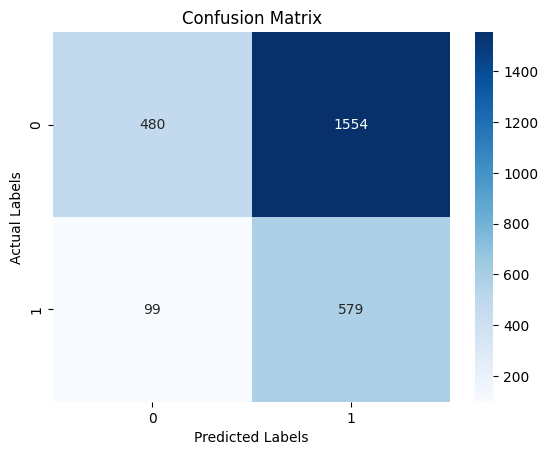

In [100]:
sns.heatmap(confusion_matrix(y_val, pred_val), fmt='d', cmap='Blues',
                    xticklabels=np.unique(y_val),
                    yticklabels=np.unique(y_val), annot=True)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')

In [92]:
print(classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.86      0.14      0.24      2034
           1       0.26      0.93      0.41       678

    accuracy                           0.34      2712
   macro avg       0.56      0.53      0.32      2712
weighted avg       0.71      0.34      0.28      2712



## CrossValidation

In [33]:
skf_test = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

In [ ]:
cv_results = cross_validate(pipe, X, y, cv=skf_test,
                                        return_train_score=True,
                                        scoring=['f1', 'accuracy',
                                    'precision', 'recall'], n_jobs=-1, verbose=3)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:  1.7min remaining:  3.9min
[Parallel(n_jobs=-1)]: Done   7 out of  10 | elapsed:  2.1min remaining:   54.7s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  2.2min finished


In [ ]:
cv_results

{'fit_time': array([92.80567527, 91.8848443 , 91.46563339, 85.48176646, 91.60370779,
        92.95248342, 92.06193352, 88.99395084, 89.67333651, 89.83595514]),
 'score_time': array([1.0497632 , 0.99598432, 0.87037158, 1.10670495, 0.92778611,
        0.97965026, 0.97987151, 1.75795317, 1.66802502, 1.4746592 ]),
 'test_f1': array([0.37512538, 0.41810345, 0.3946102 , 0.40427427, 0.4037037 ,
        0.39570278, 0.41726619, 0.42713107, 0.4137308 , 0.40144014]),
 'train_f1': array([0.40597273, 0.40299408, 0.40953717, 0.41343254, 0.41342013,
        0.41438907, 0.41125584, 0.41090399, 0.41224285, 0.41377925]),
 'test_accuracy': array([0.54056047, 0.60176991, 0.53613569, 0.50663717, 0.52507375,
        0.50221239, 0.52212389, 0.53908555, 0.52138643, 0.50958702]),
 'train_accuracy': array([0.55014749, 0.59480498, 0.55154048, 0.52196001, 0.52007539,
        0.52245166, 0.5148312 , 0.51835464, 0.52007539, 0.52171419]),
 'test_precision': array([0.28419453, 0.32937182, 0.29285714, 0.28954082, 0.29

In [ ]:
pd.DataFrame(cv_results).mean()

fit_time          90.676
score_time         1.181
test_f1            0.405
train_f1           0.411
test_accuracy      0.530
train_accuracy     0.534
test_precision     0.297
train_precision    0.301
test_recall        0.640
train_recall       0.651
dtype: float64

# Parameter Search

In [ ]:
param_grid = {'model': [DecisionTreeClassifier(random_state=SEED)],
              'model__min_samples_leaf' : [1, 2, 4, 5, 6, 10],
    'preprocessing__num_section__clipper': [OutlierClipper(rules=clipping_rules, method='manual'), None],
       
}

In [ ]:
def run_parameter_search(grid: dict,
                   cv: any,
                   X: any,
                   y: any, 
                   model: any,
                   metrics: list) -> pd.DataFrame:
    """
    Perform a manual parameter search with cross-validation to tune model
    hyperparameters. This allows us to inlcude TQDM and use it to track 
    testing progress.

    Parameters:
        ----------
         - grid (dict): Dictionary with parameters names as keys and lists
           of settings to try.
         - cv (int/generator): Determines the cross-validation splitting
         strategy.
         - X (array-like): The training input samples.
         - y (array-like): The target values.
         - model (estimator): The object to use to fit the data.
         - metrics (list): The metrics to be used for evaluating the model

    Returns:
        ----------
         pd.DataFrame: A DataFrame containing the parameters, mean/std scores
         for training and validation, and execution status.
    """
    params = ParameterGrid(grid)
    results = []
    for param in tqdm(params, desc="Tuning Hyperparameters"):
        try:
            model.set_params(**param)
            current_model = clone(model)
            cv_results = cross_validate(current_model, X, y, cv=cv,
                                        return_train_score=True,
                                        scoring=metrics, n_jobs=-1)
            param['params'] = param.copy()
            param['mean_fit_time'] = np.mean(cv_results['fit_time'])
            for metric in metrics:
                param[f'mean_val_{metric}'] = np.mean(cv_results[f'test_{metric}'])
                param[f'std_val_{metric}'] = np.std(cv_results[f'test_{metric}'])
                param[f'mean_train_{metric}'] = np.mean(cv_results[f'train_{metric}'])
                param[f'std_train_{metric}'] = np.std(cv_results[f'train_{metric}'])
            param['status'] = 'Success'
        except Exception as e:
            for metric in metrics:
                param[f'mean_val_{metric}'] = np.nan
                param[f'std_val_{metric}'] = np.nan
                param[f'mean_train_{metric}'] = np.nan
                param[f'std_train_{metric}'] = np.nan
            param['status'] = f'Failed: {str(e)[:200]}'
        results.append(param)
        df_result = pd.DataFrame(results).sort_values('mean_val_f1', ascending=False)
    return pd.DataFrame(results).sort_values('mean_val_f1', ascending=False)

result_df = run_parameter_search(grid=param_grid, cv=skf_test, X=X, y=y, model=pipe, metrics=['f1', 'accuracy',
                                    'precision', 'recall'])
result_df

X_train_t = pipe[:-1].fit_transform(X_train, y_train)
X_val_t = pipe[:-1].transform(X_val)

#number of features to try
nof_list=np.arange(2,len(X_train_t.columns))

#variables to store the optimum number of features and its corresponding score
nof=0
high_score=0

#list of scores
score_list =[]

for n in tqdm(range(len(nof_list))):
    model = DecisionTreeClassifier()

    #create instance of RFE
    rfe = RFE(model, n_features_to_select = nof_list[n])

    #fit RFE to training data - metric features only
    X_train_rfe = rfe.fit_transform(X_train_t, y_train)

    #apply the same RFE transformation to the test data
    X_test_rfe = rfe.transform(X_val_t)

    #create and train instance of Logistic Regression
    model.fit(X_train_rfe, y_train)

    #predict the test labels
    y_pred = model.predict(X_test_rfe)

    #measure f1score in variable
    f_score = f1_score(y_val, y_pred)

    #store f1score in the list of scores
    score_list.append(f_score)

    #compare against previous best performance
    if(f_score > high_score):
        high_score = f_score
        nof = nof_list[n]

print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" % (nof, high_score))

In [43]:
pipe=clone(pipe)
prepro = pipe[:-1]
X_train_t = prepro.fit_transform(X_train, y_train)
X_val_t = prepro.transform(X_val)

c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_

In [54]:
k_list = np.arange(1, 150)
scores_train = []
scores_val = []
high_score=0
nof=0
for k in tqdm(k_list):
    knn_model = TunedThresholdClassifierCV(KNeighborsClassifier(n_neighbors=k),
                                           n_jobs=-1,
                                           scoring='f1')
    knn_model.fit(X_train_t, y_train)
    train_pred = knn_model.predict(X_train_t)
    val_pred = knn_model.predict(X_val_t)
    scores_train.append(f1_score(y_train, train_pred))
    scores_val.append(f1_score(y_val, val_pred))
    if(f1_score(y_val, val_pred)>high_score):
        high_score = f1_score(y_val, val_pred)
        nof = k_list[k-1]


print("Best number of neighbors: %d" %nof)
print("Mean F1 score in train with %d neighbors: %f" % (nof, scores_train[nof-1]))
print("Mean F1 score in validation with %d neighbors: %f" % (nof, high_score))

100%|██████████| 149/149 [02:40<00:00,  1.08s/it]

Best number of neighbors: 97
Mean F1 score in train with 97 neighbors: 0.423700
Mean F1 score in validation with 97 neighbors: 0.419664


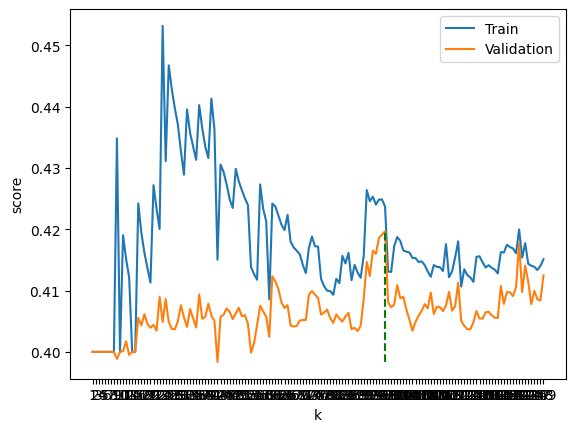

In [55]:
plt.plot(k_list, scores_train, label='Train')
plt.plot(k_list, scores_val, label = 'Validation')
plt.vlines(x=nof,ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xticks(k_list)
plt.xlabel('k')
plt.ylabel('score')
plt.legend()

plt.show()

In [56]:
knn_18 = TunedThresholdClassifierCV(KNeighborsClassifier(n_neighbors=18))
knn_18.fit(X_train_t, y_train)
knn_18.best_threshold_

np.float64(0.28619528619528617)

Text(0.5, 1.0, 'Confusion Matrix')

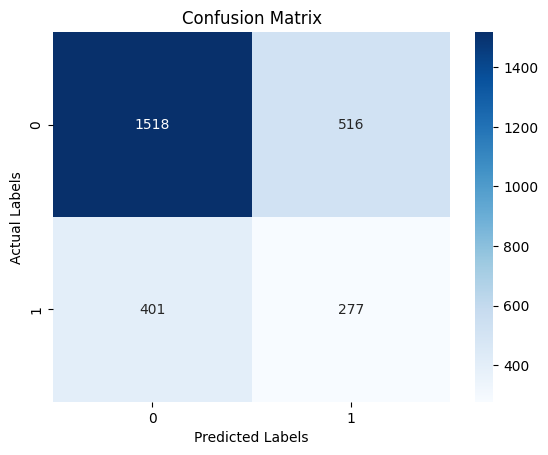

In [57]:
sns.heatmap(confusion_matrix(y_val, knn_18.predict(X_val_t)), fmt='d', cmap='Blues',
                    xticklabels=np.unique(y_val),
                    yticklabels=np.unique(y_val), annot=True)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')

In [47]:
X_train_t

,RECENCY_STATUS_96NK_E,RECENCY_STATUS_96NK_F,RECENCY_STATUS_96NK_L,RECENCY_STATUS_96NK_N,RECENCY_STATUS_96NK_S,URBANICITY_R,URBANICITY_S,URBANICITY_T,URBANICITY_U,CARD_PROM_12,CHILDREN,DONOR_AGE,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_GIFT_COUNT,LIFETIME_MIN_GIFT_AMT,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,WEALTH_RATING,LIFETIME_AVG_GIFT_AMT
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
81073,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,0.500,-0.385,0.500,0.000,0.000,-0.500,-0.200,0.286,-0.257,-0.369,-0.338,1.000,-0.500,0.000,0.083,0.474,0.136,0.192,0.000,-0.096,-0.045,-0.500,1.000,0.094,1.000,0.572,0.000,0.000,0.280,-0.306
180383,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,-1.000,-0.885,0.000,-1.000,-0.667,-0.500,0.600,0.000,0.227,0.139,0.394,-0.250,0.500,0.000,0.000,-0.053,-0.545,-0.038,0.000,-0.182,-0.045,-0.250,0.000,-0.322,-0.500,-0.386,1.000,1.000,-0.200,-0.445
30137,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,-1.000,0.500,0.192,-0.500,-1.000,-0.333,0.500,-0.700,2.143,0.360,0.300,-0.690,-0.500,0.000,0.000,0.417,-0.947,1.364,0.346,-1.000,0.646,0.864,0.600,0.000,1.288,-1.000,0.228,0.000,-1.000,-0.120,1.269
31405,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,-3.000,0.000,-0.008,-0.500,-1.000,-0.667,0.000,-0.400,0.000,-0.251,-0.230,-0.296,-0.750,-1.000,0.000,-0.083,0.316,0.045,0.038,0.000,0.124,-0.136,-0.500,2.000,0.983,0.000,0.062,0.000,0.000,-0.360,-0.476
175790,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-2.000,1.000,0.500,-0.500,-1.000,-0.667,0.000,-0.400,0.714,0.005,-0.434,-0.310,2.000,-1.000,0.000,1.917,-1.316,2.227,-0.192,-1.000,0.675,-0.045,-0.150,0.000,-0.382,-0.500,-0.386,0.000,0.000,0.120,-0.003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81061,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,-1.000,0.000,0.269,-0.500,0.000,-0.667,-0.100,0.400,-0.143,-0.257,-0.509,0.141,-0.500,0.600,0.000,0.917,-0.579,0.818,0.231,0.000,-0.242,0.227,-0.200,1.000,0.094,0.000,-0.117,1.000,0.000,-0.600,-0.149
122921,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,-1.000,-0.592,0.000,0.000,0.000,1.000,-0.500,0.714,-0.282,0.220,-0.507,0.750,0.500,0.000,-0.083,0.947,-0.500,-0.231,0.000,-0.013,0.591,0.300,2.000,0.983,0.000,0.441,0.000,0.000,0.240,0.833
98650,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-2.000,0.000,0.154,-0.500,-1.000,0.333,0.600,-0.700,2.286,-0.311,-0.289,-0.634,0.500,-1.000,0.000,-0.417,0.368,0.318,-1.462,-1.000,0.200,-0.955,0.700,-1.000,-0.858,-1.000,0.000,0.000,0.000,-0.120,1.415


# No NaN

In [58]:
data_no_nan = data.dropna()

In [59]:
len(data_no_nan) / len(data) *100

17.293510324483776

In [66]:
X_no_nan = data_no_nan.drop('TARGET_B', axis=1)
y_no_nan = data_no_nan['TARGET_B']

In [67]:
X_train_no_nan, X_val_no_nan, y_train_no_nan, y_val_no_nan = train_test_split(X_no_nan, y_no_nan, test_size=0.2, shuffle=True, stratify=y_no_nan, random_state=42)

In [68]:
pipe = clone(pipe)
pipe.fit(X_train_no_nan, y_train_no_nan)

c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\dinis\anaconda3\envs\DM2_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('cleaner', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,numerical_cols,Index(['CARD_... dtype='str')
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_section', ...), ('num_section', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_thres

In [69]:
pred_train = pipe.predict(X_train)

In [70]:
pred_val = pipe.predict(X_val)

In [71]:
f1_score(y_train, pred_train)

0.4010152284263959

In [72]:
f1_score(y_val, pred_val)

0.40524781341107874

In [73]:
pipe['model'].best_threshold_

np.float64(0.1707070707070707)

Text(0.5, 1.0, 'Confusion Matrix')

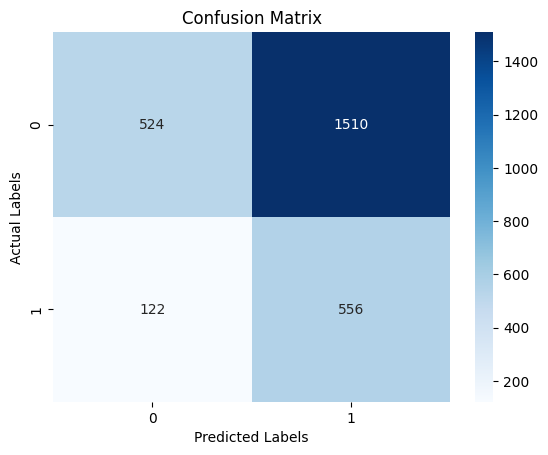

In [74]:
sns.heatmap(confusion_matrix(y_val, pred_val), fmt='d', cmap='Blues',
                    xticklabels=np.unique(y_val),
                    yticklabels=np.unique(y_val), annot=True)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')

In [ ]:
print(classification_report(y_val, pred_val))

              precision    recall  f1-score   support

           0       0.82      0.18      0.30      2034
           1       0.26      0.88      0.41       678

    accuracy                           0.36      2712
   macro avg       0.54      0.53      0.35      2712
weighted avg       0.68      0.36      0.33      2712



In [62]:
X_no_nan

,CARD_PROM_12,CHILDREN,DONOR_AGE,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,WEALTH_RATING
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
171942,6.000,3.000,40.000,2.000,4.000,5.000,5.000,18.000,93.000,14.000,10.000,4.000,45.000,824.000,221.000,55.000,15.000,15.000,13.000,0.000,29.000,39.000,30.000,55.000,0.000,8428.000,9.000,6.200,1.000,0.091,5.000,0.238,0.000,1.000
37885,6.000,4.000,69.000,2.000,2.000,6.000,20.000,18.000,105.000,7.000,20.000,5.000,46.000,520.000,217.000,182.037,16.000,16.000,15.000,0.000,4.000,25.000,0.000,57.000,0.000,7811.000,20.000,18.750,2.000,0.182,4.000,0.182,0.000,1.000
3160,6.000,2.000,87.000,3.000,2.000,4.000,25.000,19.000,98.000,7.000,25.000,5.000,66.000,1232.000,451.000,57.000,16.000,18.000,30.000,0.000,27.000,12.000,58.000,66.000,0.000,23222.000,15.000,17.330,2.000,0.250,3.000,0.158,0.000,7.000
136572,6.000,3.000,34.000,2.000,1.000,5.000,30.000,16.000,76.000,4.000,30.000,10.000,42.000,1295.000,459.000,68.000,19.000,19.000,13.000,0.000,35.000,14.000,44.000,60.000,0.000,23634.000,20.000,25.000,1.000,0.111,2.000,0.100,0.000,7.000
112521,4.000,2.000,48.000,10.000,2.000,5.000,29.000,22.000,442.000,21.000,29.000,5.000,57.000,704.000,222.000,68.000,25.000,25.000,9.000,0.000,58.000,24.000,52.000,50.000,1.000,18592.000,26.000,25.140,5.000,0.455,7.000,0.368,1.000,8.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189848,11.000,1.000,79.000,11.000,3.000,1.000,12.000,31.000,292.000,30.000,12.000,4.000,83.000,885.000,264.000,87.000,4.000,12.000,27.000,0.000,35.000,12.000,69.000,74.000,1.000,18769.000,10.000,10.000,5.000,0.500,10.000,0.476,0.000,5.000
63865,5.000,4.000,62.000,12.000,1.000,2.000,12.000,29.000,106.000,19.000,12.000,2.000,70.000,448.000,239.000,128.000,18.000,18.000,12.000,0.000,32.000,23.000,39.000,79.000,1.000,11284.000,12.000,12.000,1.000,0.143,1.000,0.059,0.000,1.000
176252,6.000,4.000,86.000,14.000,2.000,2.000,15.000,28.000,228.000,22.000,15.000,3.000,73.000,716.000,371.000,105.000,22.000,22.000,13.000,2.000,65.000,22.000,44.000,85.000,1.000,15858.000,13.600,14.000,5.000,0.455,8.000,0.381,1.000,6.000


In [ ]:
result_df = run_parameter_search(grid=param_grid, cv=skf_test, X=X_no_nan, y=y_no_nan, model=pipe, metrics=['f1', 'accuracy',
                                    'precision', 'recall'])
result_df

## Ignore for now

k_list = np.arange(1, 20)
scores_train = []
scores_val = []
high_score=0
nof=0
for k in k_list:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_no_nan, y_train_no_nan)
    train_pred = knn_model.predict(X_train_no_nan)
    val_pred = knn_model.predict(X_val_t)
    scores_train.append(f1_score(y_train_no_nan, train_pred))
    scores_val.append(f1_score(y_val_no_nan, val_pred))
    if(f1_score(y_val_no_nan, val_pred)>high_score):
        high_score = f1_score(y_val_no_nan, val_pred)
        nof = k_list[k-1]


print("Best number of neighbors: %d" %nof)
print("Mean F1 score in train with %d neighbors: %f" % (nof, scores_train[nof-1]))
print("Mean F1 score in validation with %d neighbors: %f" % (nof, high_score))

plt.plot(k_list, scores_train, label='Train')
plt.plot(k_list, scores_val, label = 'Validation')
plt.vlines(x=nof,ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xticks(k_list)
plt.xlabel('k')
plt.ylabel('score')
plt.legend()

plt.show()